### Customer Churn Prediction
## Exploratory Data Analysis & Machine Learning

This notebook presents an end-to-end customer churn analysis, including data cleaning, exploratory data analysis, preprocessing, machine learning model comparison, and churn-driver interpretation.

The objective is to identify customers at risk of churn and extract actionable insights that can support customer-retention decisions.

### Import Libraries

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [92]:
df = pd.read_csv("../data/telco_customer_churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
# Dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [94]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Data Cleaning

Although the dataset initially appeared to contain no missing values, `TotalCharges` was stored as an object column and contained 11 blank-string values. These values were converted to numeric using coercion, producing missing values, and the affected rows were removed.

After cleaning, the dataset contains **7,032 customer records and 21 columns**, with no duplicate rows.

In [95]:
# Check blank values in TotalCharges
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [96]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [97]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Verify dataset shape
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7032, 21)


In [98]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [99]:
# Check target distribution
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [100]:
# Check target distribution (%)
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

### Target Variable Distribution

The target variable is moderately imbalanced. Approximately **73.4%** of customers remained, while **26.6%** churned.

Because identifying customers at risk of churn is the main business objective, model evaluation should consider **precision, recall, F1-score, and ROC-AUC**, rather than relying on accuracy alone.

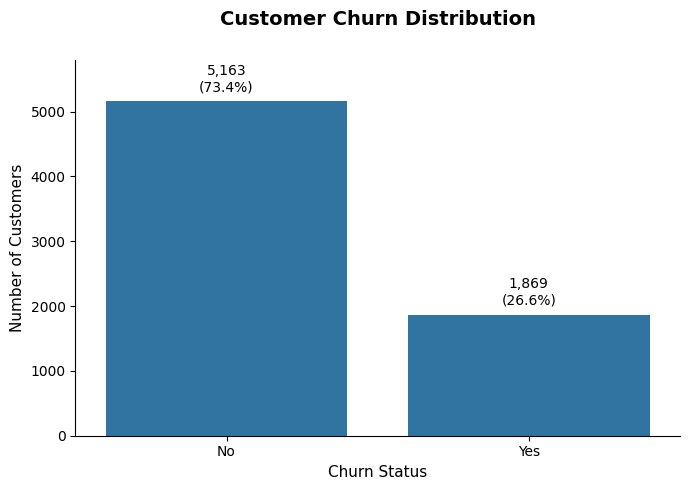

In [101]:
# Customer Churn Distribution

# Create figure
plt.figure(figsize=(7, 5))

# Create count plot
ax = sns.countplot(data=df, x='Churn')

# Add title and axis labels
plt.title(
    'Customer Churn Distribution',
    fontsize=14,
    fontweight='bold',
    pad=25
)

plt.xlabel('Churn Status', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)

# Add customer count and percentage above each bar
for container in ax.containers:
    labels = [
        f'{int(bar.get_height()):,}\n({bar.get_height() / len(df) * 100:.1f}%)'
        for bar in container
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        padding=5,
        fontsize=10
    )

# Add extra space above bars
plt.ylim(0, 5800)

# Clean chart appearance
sns.despine()

# Adjust layout
plt.tight_layout()

# Save chart for README
plt.savefig(
    '../images/churn_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

# Display chart
plt.show()

## Churn Drivers Analysis

To better understand customer churn, we examine how churn varies across key customer characteristics, including contract type, tenure, monthly charges, and internet service.

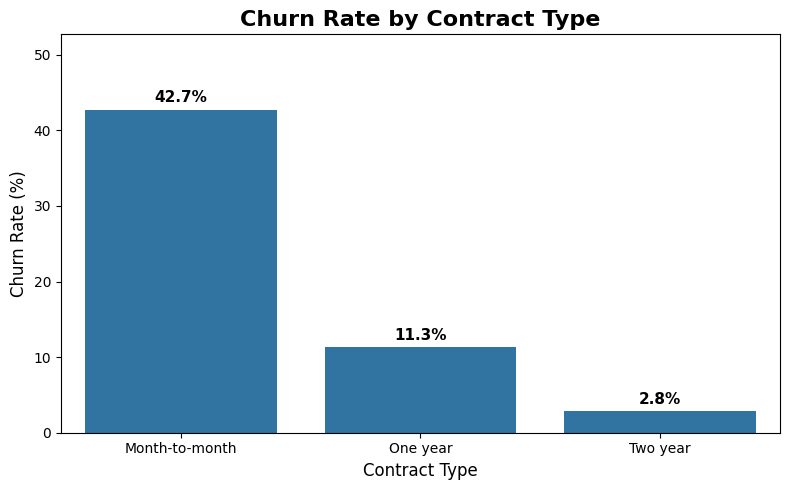

In [102]:
# Churn rate by contract type

contract_churn = (
    df.groupby('Contract')['Churn']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

# Add percentage labels
for i, value in enumerate(contract_churn.values):
    plt.text(
        i,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, max(contract_churn.values) + 10)
plt.tight_layout()

plt.savefig(
    '../images/churn_by_contract.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Insight

Customers on month-to-month contracts have by far the highest churn rate (42.7%), compared with 11.3% for one-year contracts and only 2.8% for two-year contracts.

This suggests that longer-term contracts are strongly associated with customer retention. From a business perspective, month-to-month customers should be prioritized for retention campaigns and incentives that encourage longer contract commitments.

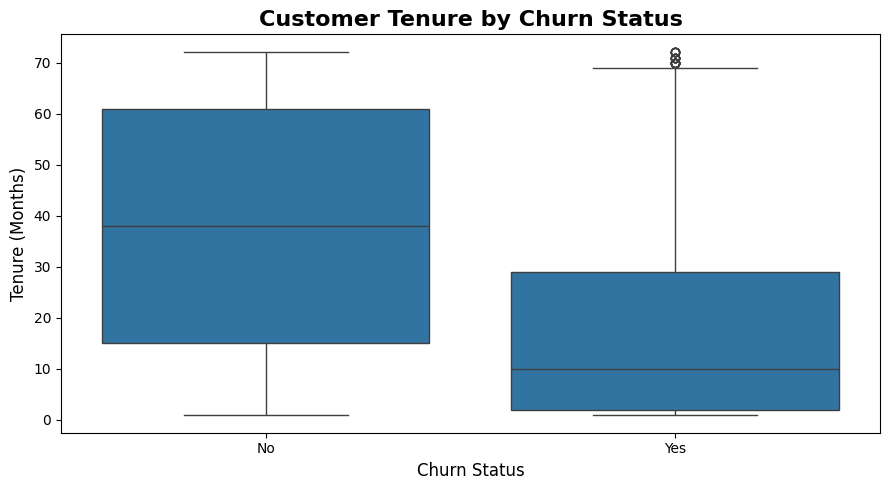

In [103]:
# Tenure distribution by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)

plt.title('Customer Tenure by Churn Status',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

plt.tight_layout()

plt.savefig(
    '../images/tenure_by_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

Customers who churn tend to have **substantially shorter tenure** than customers who remain.

The median tenure of churned customers is approximately **10 months**, compared with approximately **38 months** for retained customers.

This suggests that **newer customers are at greater risk of churn**, highlighting the importance of customer retention strategies during the early stages of the customer relationship.

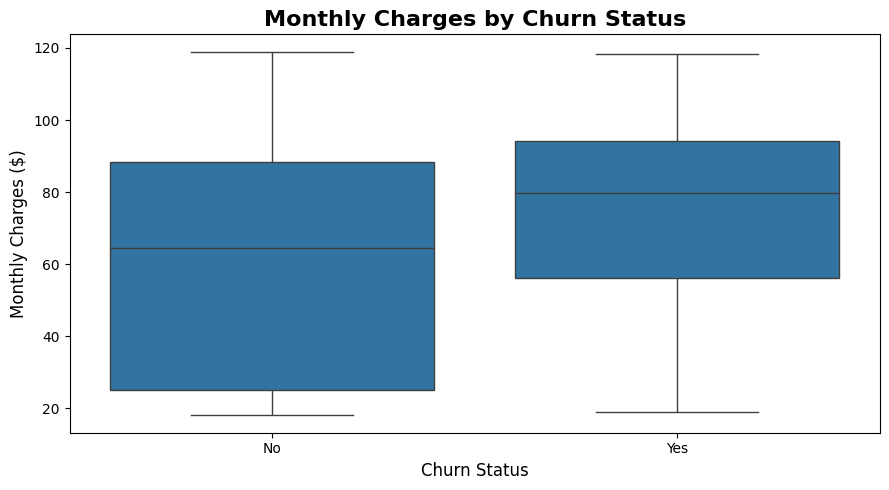

In [104]:
# Monthly charges distribution by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

plt.title(
    'Monthly Charges by Churn Status',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()

plt.savefig(
    '../images/monthly_charges_by_churn.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Key Finding

Customers who churn tend to have **higher monthly charges** than customers who remain.

The distribution of monthly charges is shifted upward for churned customers, suggesting that **higher monthly costs are associated with an increased likelihood of churn**.

This suggests that monthly charges may be a useful feature for predicting customer churn.

## Machine Learning Modeling

### Data Preparation

In [105]:
# Prepare data for modeling

model_df = df.copy()

# Convert target variable to binary
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

# Remove customer ID because it has no predictive meaning
model_df = model_df.drop(columns=["customerID"])

# Separate features and target
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Feature matrix shape: (7032, 19)
Target shape: (7032,)

Target distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [106]:
# Encode categorical features

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

X_encoded.head()

Original feature shape: (7032, 19)
Encoded feature shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)

Training target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [108]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Accuracy: 0.804
Precision: 0.648
Recall: 0.575
F1-score: 0.609
ROC-AUC: 0.836


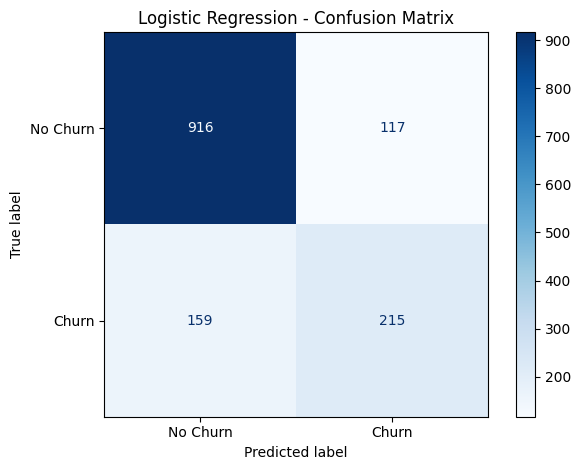

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

### Model Evaluation – Key Finding

The baseline Logistic Regression model achieved **80.4% accuracy** and a **ROC-AUC of 0.836**, indicating good overall discrimination between customers who churn and those who remain.

However, the model identified only **57.5% of actual churners (recall)**, correctly detecting 215 of 374 churn cases while missing 159 customers who eventually churned.

From a customer-retention perspective, these false negatives are particularly important because they represent at-risk customers who would not be targeted by retention interventions.

This baseline therefore provides a strong starting point, while further model development should focus on **improving churn recall without introducing excessive false positives**.

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [111]:
print("Random Forest Performance")
print("-------------------------")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Precision:", round(precision_score(y_test, rf_pred), 3))
print("Recall:", round(recall_score(y_test, rf_pred), 3))
print("F1-score:", round(f1_score(y_test, rf_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))

Random Forest Performance
-------------------------
Accuracy: 0.787
Precision: 0.629
Recall: 0.489
F1-score: 0.55
ROC-AUC: 0.82


### Model Comparison – Key Finding

The baseline Logistic Regression model outperformed the Random Forest model across all evaluated metrics.

Logistic Regression achieved a ROC-AUC of 0.836 and a recall of 57.5%, compared with a ROC-AUC of 0.820 and a recall of 48.9% for Random Forest.

Since identifying customers at risk of churn is a key business objective, recall is particularly important. Based on the current results, Logistic Regression provides the stronger baseline model.

Further improvements will focus on increasing churn recall while maintaining an acceptable precision–recall trade-off.

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

lr_balanced.fit(X_train, y_train)

lr_balanced_pred = lr_balanced.predict(X_test)
lr_balanced_prob = lr_balanced.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


In [113]:
print("Balanced Logistic Regression Performance")
print("----------------------------------------")
print("Accuracy:", round(accuracy_score(y_test, lr_balanced_pred), 3))
print("Precision:", round(precision_score(y_test, lr_balanced_pred), 3))
print("Recall:", round(recall_score(y_test, lr_balanced_pred), 3))
print("F1-score:", round(f1_score(y_test, lr_balanced_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_balanced_prob), 3))

Balanced Logistic Regression Performance
----------------------------------------
Accuracy: 0.726
Precision: 0.491
Recall: 0.797
F1-score: 0.608
ROC-AUC: 0.835


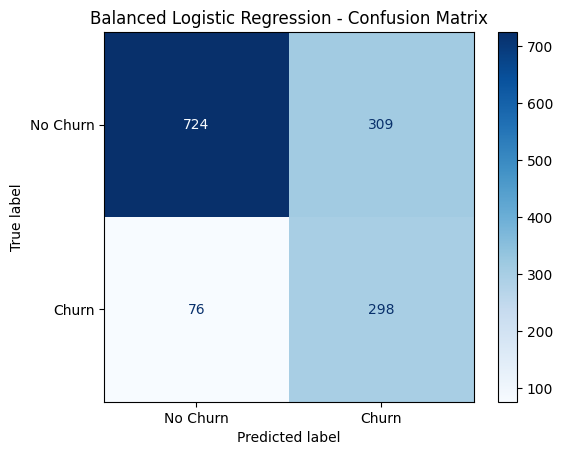

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(y_test, lr_balanced_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.savefig(
    "../images/balanced_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Balanced Logistic Regression – Key Finding

Using class weighting substantially improved the model's ability to identify customers at risk of churn.

Recall increased from **57.5% to 79.7%**, reducing false negatives from **159 to 76**. The balanced model correctly identified **298 of 374 actual churners**, compared with 215 using the baseline Logistic Regression model.

This improvement comes with a trade-off: false positives increased, resulting in lower precision and overall accuracy. However, in a customer-retention context, missing an actual churner may be more costly than contacting a customer who would otherwise remain.

Therefore, the balanced Logistic Regression model provides a stronger candidate when the business priority is early identification of customers at risk of churn.

In [115]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [0.804, 0.787, 0.726],
    "Precision": [0.648, 0.629, 0.491],
    "Recall": [0.575, 0.489, 0.797],
    "F1-score": [0.609, 0.550, 0.608],
    "ROC-AUC": [0.836, 0.820, 0.835]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.804,0.648,0.575,0.609,0.836
1,Random Forest,0.787,0.629,0.489,0.550,0.820
2,Balanced Logistic Regression,0.726,0.491,0.797,0.608,0.835


## Final Model Selection

The **Balanced Logistic Regression** model was selected as the preferred model for this customer churn use case.

Although the baseline Logistic Regression achieved higher accuracy (80.4%) and precision (64.8%), the balanced model substantially improved **recall from 57.5% to 79.7%**, while maintaining a similar ROC-AUC (0.835 vs. 0.836).

From a customer-retention perspective, recall is particularly important because false negatives represent customers who are likely to churn but would not be identified for intervention.

The balanced model therefore provides a more suitable trade-off for a churn-prevention strategy, where identifying a larger proportion of at-risk customers is prioritized over maximizing overall accuracy.

In [116]:
# Feature importance from the selected Balanced Logistic Regression pipeline

# Extract the fitted Logistic Regression model from the pipeline
balanced_lr_model = lr_balanced.named_steps["model"]

# Extract coefficients
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": balanced_lr_model.coef_[0]
})

# Rank features by strength of effect
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

# Show top 15 most influential features
feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.263854,1.263854
2,MonthlyCharges,-0.928682,0.928682
10,InternetService_Fiber optic,0.746144,0.746144
25,Contract_Two year,-0.638598,0.638598
3,TotalCharges,0.623279,0.623279
24,Contract_One year,-0.326693,0.326693
21,StreamingTV_Yes,0.259691,0.259691
23,StreamingMovies_Yes,0.252870,0.252870
9,MultipleLines_Yes,0.202763,0.202763
28,PaymentMethod_Electronic check,0.193697,0.193697


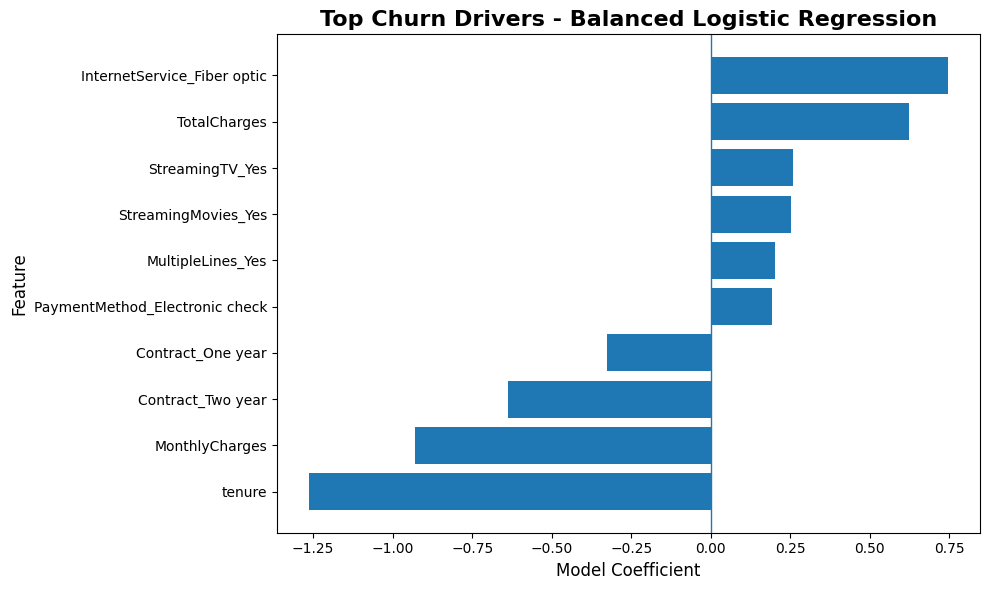

In [117]:
# Visualize top feature coefficients

top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Top Churn Drivers - Balanced Logistic Regression",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.tight_layout()

plt.savefig(
    "../images/top_churn_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance – Key Finding

The selected Balanced Logistic Regression model highlights several important patterns associated with customer churn.

**Fiber-optic internet service** shows the strongest positive coefficient among the analyzed features, indicating a higher predicted likelihood of churn, while **longer customer tenure** shows the strongest negative coefficient.

Long-term contracts, particularly **two-year contracts**, are also associated with a lower predicted likelihood of churn.

These findings suggest that customer retention strategies should pay particular attention to newer customers and customer segments associated with higher churn predictions.

> **Note:** Logistic Regression coefficients describe associations within the model and should not be interpreted as causal effects.

## Business Recommendations

Based on the exploratory analysis and the selected churn prediction model, the following actions could support customer-retention efforts:

1. **Prioritize newer customers**
   - Customer tenure was one of the strongest features associated with churn predictions.
   - Retention initiatives could therefore focus on customers during the earlier stages of their relationship with the company.

2. **Investigate the fiber-optic customer segment**
   - Fiber-optic internet service showed a strong positive association with predicted churn.
   - Further analysis of pricing, service quality, customer satisfaction, and support interactions within this segment could help identify potential drivers.

3. **Encourage longer-term contracts**
   - One-year and two-year contracts were associated with lower predicted churn.
   - Appropriate incentives for customers to move toward longer-term contracts could potentially support retention.

4. **Use the model for targeted retention**
   - The Balanced Logistic Regression model identified 79.7% of actual churners in the test set.
   - Rather than targeting all customers, predicted high-risk customers could be prioritized for retention campaigns.

### Business Consideration

The model should be used as a decision-support tool rather than an automated decision system. Before deployment, retention actions should be evaluated against their costs and the business impact of false positives and false negatives.

## Conclusion

This project developed a machine learning approach to identify customers at risk of churn and translate model results into actionable retention insights.

Three models were evaluated: Logistic Regression, Random Forest, and Balanced Logistic Regression. While the baseline Logistic Regression achieved the highest accuracy (80.4%), the Balanced Logistic Regression was selected as the preferred model because it increased churn recall from 57.5% to 79.7%, while maintaining a similar ROC-AUC (0.835).

The final model identified 298 of 374 actual churners in the test set, substantially reducing the number of missed at-risk customers.

Feature analysis highlighted customer tenure, contract type, fiber-optic internet service, and several service-related characteristics as important predictors in the model.

Overall, the results demonstrate how predictive modeling can support a more targeted customer-retention strategy by helping businesses identify and prioritize customers with elevated churn risk.

### Next Steps

Future improvements could include:
- Hyperparameter and decision-threshold optimization
- Cross-validation for more robust model evaluation
- Testing additional models such as XGBoost or LightGBM
- Probability calibration and cost-sensitive evaluation
- Deployment of the final model as a simple churn-risk scoring application

## Key Observation

The target variable is moderately imbalanced, with approximately 73% of customers retained and 27% having churned. This class imbalance should be considered during model evaluation.

In [119]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline: scaling + balanced logistic regression
tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    ))
])

# Values of C to test
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# 5-fold cross-validation, optimizing for recall
grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best C:", grid_search.best_params_['model__C'])
print("Best Cross-Validation Recall:", round(grid_search.best_score_, 3))

Best C: 1
Best Cross-Validation Recall: 0.803


In [120]:
from sklearn.metrics import precision_score, recall_score, f1_score

best_model = grid_search.best_estimator_

# Predicted churn probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold 0.3 | Precision: 0.415 | Recall: 0.928 | F1: 0.573
Threshold 0.4 | Precision: 0.452 | Recall: 0.872 | F1: 0.595
Threshold 0.5 | Precision: 0.491 | Recall: 0.797 | F1: 0.608
Threshold 0.6 | Precision: 0.544 | Recall: 0.717 | F1: 0.618
Threshold 0.7 | Precision: 0.608 | Recall: 0.615 | F1: 0.612


Threshold Selection

A decision threshold of 0.4 was selected to prioritize recall.
At this threshold, the model identifies 87.2% of actual churners, while maintaining a precision of 45.2%.

In [121]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Gradient Boosting Results")
print("Accuracy:", round(accuracy_score(y_test, gb_pred), 3))
print("Precision:", round(precision_score(y_test, gb_pred), 3))
print("Recall:", round(recall_score(y_test, gb_pred), 3))
print("F1-score:", round(f1_score(y_test, gb_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, gb_prob), 3))

Gradient Boosting Results
Accuracy: 0.795
Precision: 0.638
Recall: 0.532
F1-score: 0.58
ROC-AUC: 0.841


### Additional Model Experiment

Gradient Boosting was tested as an additional model.

Although it achieved a ROC-AUC of **0.841** and precision of **0.638**, 
its recall was only **0.532**.

Since identifying potential churners is the main business objective, 
the tuned Balanced Logistic Regression remains the preferred model.

### Additional Model Experiment

Gradient Boosting was tested as an additional model.

Although it achieved a ROC-AUC of **0.841** and precision of **0.638**, its recall was only **0.532**.

Since identifying potential churners is the main business objective, the tuned Balanced Logistic Regression remains the preferred model.